# Visualización de Atención - CNN-BiLSTM-Attention

Este notebook carga un modelo entrenado con atención (Thomas et al., 2025) y visualiza cómo atiende a diferentes partes de las curvas de luz para hacer predicciones.

## Visualizaciones:
- **3 ejemplos de Clase 1 (Planetas confirmados)**
- **3 ejemplos de Clase 0 (No planetas / Falsos positivos astrofísicos)**

In [77]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Configuración
SEED = 42
np.random.seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Directorios
DATA_DIR = Path("data/processed")
MODELS_DIR = Path("models")

print("✓ Librerías cargadas")

Device: cpu
✓ Librerías cargadas


In [78]:
# Cargar datos de test
df_test = pd.read_csv(DATA_DIR / "test.csv")
print(f"✓ Test set: {len(df_test):,} samples")

# Identificar columnas de features
global_cols = [c for c in df_test.columns if c.startswith('global_')]
local_cols = [c for c in df_test.columns if c.startswith('local_')]
feature_cols = global_cols + local_cols

print(f"  - Global view: {len(global_cols)} features")
print(f"  - Local view: {len(local_cols)} features")

# Dataset class
class ExoplanetDataset(Dataset):
    def __init__(self, df: pd.DataFrame, feature_cols: list[str]):
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.labels = torch.tensor(df['label'].values, dtype=torch.float32)
    
    def __len__(self) -> int:
        return len(self.labels)
    
    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.features[idx], self.labels[idx]

test_dataset = ExoplanetDataset(df_test, feature_cols)
print(f"✓ Dataset creado")

✓ Test set: 1,574 samples
  - Global view: 2001 features
  - Local view: 201 features
✓ Dataset creado


In [79]:
class AdditiveAttention(nn.Module):
    """
    Additive Attention mechanism (Bahdanau attention).
    
    Computes: attention_weights = softmax(tanh(W @ h))
    Context vector = sum(attention_weights * hidden_states)
    """
    
    def __init__(self, hidden_dim: int, projection_dim: int | None = None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.projection_dim = projection_dim or hidden_dim
        
        # Attention score computation
        self.attention_fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, hidden_states: torch.Tensor, return_weights: bool = False):
        """
        Args:
            hidden_states: (batch, seq_len, hidden_dim)
            return_weights: If True, also return attention weights
            
        Returns:
            context: (batch, hidden_dim)
            attention_weights: (batch, seq_len) if return_weights=True
        """
        # Compute attention scores: (batch, seq_len, 1)
        scores = torch.tanh(self.attention_fc(hidden_states))
        
        # Softmax over sequence dimension: (batch, seq_len, 1)
        attention_weights = torch.softmax(scores, dim=1)
        
        # Weighted sum: (batch, hidden_dim)
        context = torch.sum(attention_weights * hidden_states, dim=1)
        
        if return_weights:
            return context, attention_weights.squeeze(-1)
        return context

print("✓ AdditiveAttention definida")

class ThomasCNNBiLSTMDual(nn.Module):
    """
    CNN + BiLSTM + Attention architecture from Thomas et al., 2025.
    
    AMBAS RAMAS (local y global) tienen la MISMA arquitectura:
    
    CNN FEATURE EXTRACTION (5 bloques):
        - Block 1: 16 filters, kernel=5, padding=same, 2×Conv1D+ReLU, Dropout(0.2), MaxPool(5, stride=2)
        - Block 2: 32 filters
        - Block 3: 64 filters
        - Block 4: 128 filters
        - Block 5: 256 filters
    
    BIDIRECTIONAL LSTM (2 capas):
        - 128 units por capa, bidirectional → 256 output
        - Dropout: 0.3
    
    ATTENTION:
        - Dense(1, tanh), Softmax, weighted sum → 256 dims
    
    FUSION:
        - Concatenate: 256 (global) + 256 (local) = 512 dims
        - 4 × Dense(1024) + ReLU + Dropout(0.2)
        - Output(1)
    """
    
    def __init__(
        self,
        local_seq_len: int = 201,
        global_seq_len: int = 2001,
        cnn_dropout: float = 0.2,
        lstm_dropout: float = 0.3,
        fc_dropout: float = 0.2
    ):
        super().__init__()
        self.local_seq_len = local_seq_len
        self.global_seq_len = global_seq_len
        self.cnn_dropout = cnn_dropout
        
        # ============================================================
        # LOCAL BRANCH - Thomas et al., 2025
        # 5 blocks, filters 16→32→64→128→256, kernel=5, pool=5/2
        # BiLSTM: 2 layers, 128 units, dropout=0.3
        # ============================================================
        self.local_cnn = self._build_cnn_blocks()
        self.local_bilstm = nn.LSTM(
            input_size=256,  # Output of CNN block 5
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout
        )
        self.local_bilstm_dropout = nn.Dropout(lstm_dropout)
        self.local_attention = AdditiveAttention(256)  # 128*2 (bidirectional)
        
        # ============================================================
        # GLOBAL BRANCH - Thomas et al., 2025 (misma arquitectura)
        # 5 blocks, filters 16→32→64→128→256, kernel=5, pool=5/2
        # BiLSTM: 2 layers, 128 units, dropout=0.3
        # ============================================================
        self.global_cnn = self._build_cnn_blocks()
        self.global_bilstm = nn.LSTM(
            input_size=256,  # Output of CNN block 5
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout
        )
        self.global_bilstm_dropout = nn.Dropout(lstm_dropout)
        self.global_attention = AdditiveAttention(256)  # 128*2 (bidirectional)
        
        # ============================================================
        # CLASSIFICATION HEAD - 4 × Dense(1024) + Output(1)
        # ============================================================
        # fusion_dim = 256 (local) + 256 (global) = 512
        fusion_dim = 256 + 256
        
        # 4 hidden layers of 1024 units each
        fc_layers = []
        in_features = fusion_dim
        for _ in range(4):
            fc_layers.extend([
                nn.Linear(in_features, 1024),
                nn.ReLU(),
                nn.Dropout(fc_dropout)
            ])
            in_features = 1024
        self.fc = nn.Sequential(*fc_layers)
        self.output = nn.Linear(1024, 1)
        
        self._init_weights()
    
    def _build_cnn_blocks(self) -> nn.ModuleList:
        """
        Build 5 CNN blocks as per Thomas et al., 2025.
        Each block: 2×Conv1D(kernel=5, padding=same) + ReLU + Dropout(0.2) + MaxPool(5, stride=2)
        Filters: 16 → 32 → 64 → 128 → 256
        """
        blocks = nn.ModuleList()
        filter_sizes = [16, 32, 64, 128, 256]
        in_channels = 1
        
        for num_filters in filter_sizes:
            block = nn.Sequential(
                # Conv1D layer 1
                nn.Conv1d(in_channels, num_filters, kernel_size=5, padding='same'),
                nn.ReLU(),
                # Conv1D layer 2
                nn.Conv1d(num_filters, num_filters, kernel_size=5, padding='same'),
                nn.ReLU(),
                # Dropout after conv layers
                nn.Dropout(self.cnn_dropout),
                # MaxPool
                nn.MaxPool1d(kernel_size=5, stride=2)
            )
            blocks.append(block)
            in_channels = num_filters
        
        return blocks
    
    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name or 'weight_hh' in name:
                        nn.init.kaiming_uniform_(param, nonlinearity='relu')
                    elif 'bias' in name:
                        nn.init.zeros_(param)
    
    def forward(self, x: torch.Tensor, return_attention: bool = False):
        """
        Args:
            x: (batch, total_seq_len) = (batch, global_len + local_len)
               Features are ordered: [global_cols..., local_cols...]
        """
        attn_weights_dict = {}
        
        # LOCAL BRANCH
        local_x = x[:, self.global_seq_len:self.global_seq_len + self.local_seq_len]
        local_x = local_x.unsqueeze(1)  # (batch, 1, seq)
        
        # CNN blocks: 5 blocks of 2×Conv1D + Dropout + MaxPool
        for block in self.local_cnn:
            local_x = block(local_x)  # Final: (batch, 256, reduced_seq)
        
        # BiLSTM
        local_x = local_x.transpose(1, 2)  # (batch, seq, 256)
        local_x, _ = self.local_bilstm(local_x)  # (batch, seq, 256)
        local_x = self.local_bilstm_dropout(local_x)
        
        # Attention
        if return_attention:
            local_context, attn = self.local_attention(local_x, return_weights=True)
            attn_weights_dict['local'] = attn
        else:
            local_context = self.local_attention(local_x)  # (batch, 256)
        
        # GLOBAL BRANCH
        global_x = x[:, :self.global_seq_len]
        global_x = global_x.unsqueeze(1)  # (batch, 1, seq)
        
        # CNN blocks: 5 blocks of 2×Conv1D + Dropout + MaxPool
        for block in self.global_cnn:
            global_x = block(global_x)  # Final: (batch, 256, reduced_seq)
        
        # BiLSTM
        global_x = global_x.transpose(1, 2)  # (batch, seq, 256)
        global_x, _ = self.global_bilstm(global_x)  # (batch, seq, 256)
        global_x = self.global_bilstm_dropout(global_x)
        
        # Attention
        if return_attention:
            global_context, attn = self.global_attention(global_x, return_weights=True)
            attn_weights_dict['global'] = attn
        else:
            global_context = self.global_attention(global_x)  # (batch, 256)
        
        # FUSION
        fused = torch.cat([global_context, local_context], dim=1)  # (batch, 512)
        x = self.fc(fused)  # 4 × Dense(1024)
        x = self.output(x)  # (batch, 1)
        
        if return_attention:
            return x.squeeze(-1), attn_weights_dict
        return x.squeeze(-1)

print("✓ Modelo ThomasCNNBiLSTMDual definido (Thomas et al., 2025)")
print("  - Local: 5 CNN blocks (16→256) + BiLSTM(128×2) + Attention → 256 dims")
print("  - Global: 5 CNN blocks (16→256) + BiLSTM(128×2) + Attention → 256 dims")
print("  - Fusion: 512 dims → 4 × Dense(1024) → Output(1)")

✓ AdditiveAttention definida
✓ Modelo ThomasCNNBiLSTMDual definido (Thomas et al., 2025)
  - Local: 5 CNN blocks (16→256) + BiLSTM(128×2) + Attention → 256 dims
  - Global: 5 CNN blocks (16→256) + BiLSTM(128×2) + Attention → 256 dims
  - Fusion: 512 dims → 4 × Dense(1024) → Output(1)


In [80]:
# ============================================================
# Cargar modelo entrenado
# ============================================================

MODEL_NAME = "cnn-bilstm-attention_dual_bce_no_strat_0"  # Mejor modelo BCE + Stratified
model_path = MODELS_DIR / f"{MODEL_NAME}.pt"

# Crear modelo y cargar pesos
model = ThomasCNNBiLSTMDual(
    cnn_dropout=0.2,
    lstm_dropout=0.3,
    fc_dropout=0.2
).to(device)

checkpoint = torch.load(model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Modelo cargado: {MODEL_NAME}")
print(f"  - Loss type: {checkpoint['hyperparameters']['loss_type']}")
print(f"  - Stratified: {checkpoint['hyperparameters']['use_stratified_sampling']}")
print(f"  - Test F1: {checkpoint['test_results']['f1']:.4f}")
print(f"  - Test AUC-ROC: {checkpoint['test_results']['auc_roc']:.4f}")

✓ Modelo cargado: cnn-bilstm-attention_dual_bce_no_strat_0
  - Loss type: BCE
  - Stratified: False
  - Test F1: 0.7328
  - Test AUC-ROC: 0.9789


In [81]:
# ============================================================
# Función de visualización de atención
# ============================================================

def visualize_attention(
    model: nn.Module,
    sample_features: torch.Tensor,
    sample_label: int,
    title_prefix: str = "",
    global_len: int = 2001,
    local_len: int = 201,
) -> None:
    """
    Visualiza la curva de luz (Global + Local) junto con los pesos de atención.
    """
    model.eval()
    device = next(model.parameters()).device
    
    # Obtener predicción y pesos de atención
    with torch.no_grad():
        sample = sample_features.unsqueeze(0).to(device)
        logit, attn_weights_dict = model(sample, return_attention=True)
        prob = torch.sigmoid(logit).item()
        pred = 1 if prob > 0.5 else 0
        
        local_attn_raw = attn_weights_dict['local'].squeeze(0).cpu().numpy()
        global_attn_raw = attn_weights_dict['global'].squeeze(0).cpu().numpy()
    
    # Separar global y local views
    features_np = sample_features.cpu().numpy()
    global_view = features_np[:global_len]
    local_view = features_np[global_len:global_len + local_len]
    
    # Expandir atención a la secuencia original
    attn_local = np.interp(
        np.linspace(0, len(local_attn_raw)-1, local_len),
        np.arange(len(local_attn_raw)),
        local_attn_raw
    )
    attn_global = np.interp(
        np.linspace(0, len(global_attn_raw)-1, global_len),
        np.arange(len(global_attn_raw)),
        global_attn_raw
    )
    
    # Crear figura
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.subplots_adjust(wspace=0.3)
    
    # Título con predicción (sin emojis)
    label_str = "Planeta" if sample_label == 1 else "No Planeta"
    pred_str = "Planeta" if pred == 1 else "No Planeta"
    correct = "[OK]" if pred == sample_label else "[X]"
    fig.suptitle(f'{title_prefix}Prediccion: {pred_str} (prob={prob:.3f}) | Real: {label_str} {correct}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # 1. Global View + Atención
    ax1 = axes[0]
    ax1.plot(global_view, 'b-', linewidth=0.5, alpha=0.6, label='Flujo')
    ax1_twin = ax1.twinx()
    ax1_twin.fill_between(range(len(attn_global)), attn_global, alpha=0.3, color='red')
    ax1_twin.plot(attn_global, 'r-', linewidth=0.5, alpha=0.7, label='Atención')
    ax1.set_title('Global View + Atención')
    ax1.set_xlabel('Tiempo (binned)')
    ax1.set_ylabel('Flujo normalizado', color='blue')
    ax1_twin.set_ylabel('Peso de atención', color='red')
    ax1.grid(True, alpha=0.3)
    
    # 2. Local View + Atención
    ax2 = axes[1]
    ax2.plot(local_view, 'g-', linewidth=1, alpha=0.6, label='Flujo')
    ax2_twin = ax2.twinx()
    ax2_twin.fill_between(range(len(attn_local)), attn_local, alpha=0.3, color='red')
    ax2_twin.plot(attn_local, 'r-', linewidth=1, alpha=0.7, label='Atención')
    ax2.set_title('Local View + Atención')
    ax2.set_xlabel('Tiempo (centrado en tránsito)')
    ax2.set_ylabel('Flujo normalizado', color='green')
    ax2_twin.set_ylabel('Peso de atención', color='red')
    ax2.grid(True, alpha=0.3)
    
    # 3. Distribución de atención
    ax3 = axes[2]
    total_attn_global = attn_global.sum()
    total_attn_local = attn_local.sum()
    max_val = max(total_attn_global, total_attn_local)
    bars = ax3.bar(['Global', 'Local'], 
                   [total_attn_global, total_attn_local],
                   color=['steelblue', 'seagreen'], alpha=0.8)
    ax3.set_ylabel('Suma de pesos de atencion')
    ax3.set_title('Distribucion de atencion')
    ax3.set_ylim(0, max_val * 1.2)  # Dar espacio para los números
    
    # Añadir valores en las barras
    for bar, val in zip(bars, [total_attn_global, total_attn_local]):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val * 0.03, 
                 f'{val:.1f}', ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()

print("✓ Función visualize_attention definida")

✓ Función visualize_attention definida


In [82]:
# ============================================================
# Seleccionar ejemplos de cada clase
# ============================================================

# Encontrar índices de cada clase
planet_indices = [i for i, (_, label) in enumerate(test_dataset) if label == 1]
no_planet_indices = [i for i, (_, label) in enumerate(test_dataset) if label == 0]

print(f"🪐 Planetas en test: {len(planet_indices)}")
print(f"❌ No planetas en test: {len(no_planet_indices)}")

# Seleccionar 3 ejemplos aleatorios de cada clase
np.random.seed(123)  # Semilla diferente para variedad
selected_planets = np.random.choice(planet_indices, 3, replace=False)
selected_no_planets = np.random.choice(no_planet_indices, 3, replace=False)

print(f"\nÍndices seleccionados:")
print(f"  Planetas: {selected_planets}")
print(f"  No planetas: {selected_no_planets}")

🪐 Planetas en test: 360
❌ No planetas en test: 1214

Índices seleccionados:
  Planetas: [ 743 1098   61]
  No planetas: [585 969 912]


## 🪐 Clase 1: Planetas Confirmados

Visualización de la atención del modelo en 3 ejemplos de planetas confirmados del conjunto de test.

PLANETA 1


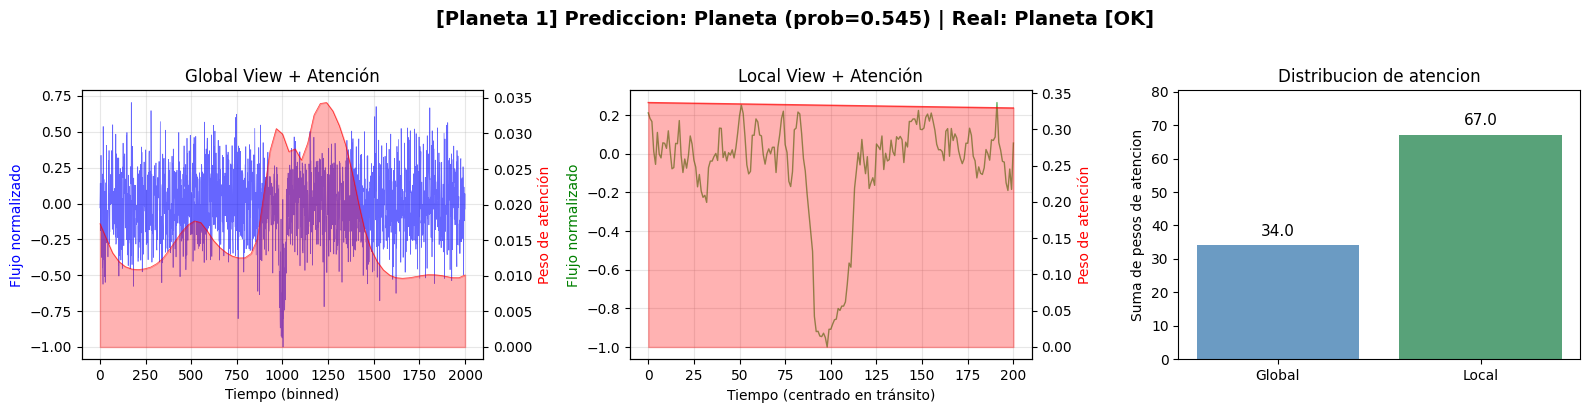

In [83]:
# Planeta 1
print("=" * 70)
print("PLANETA 1")
print("=" * 70)
idx = selected_planets[0]
features, label = test_dataset[idx]
visualize_attention(model, features, int(label.item()), title_prefix="[Planeta 1] ")

PLANETA 2


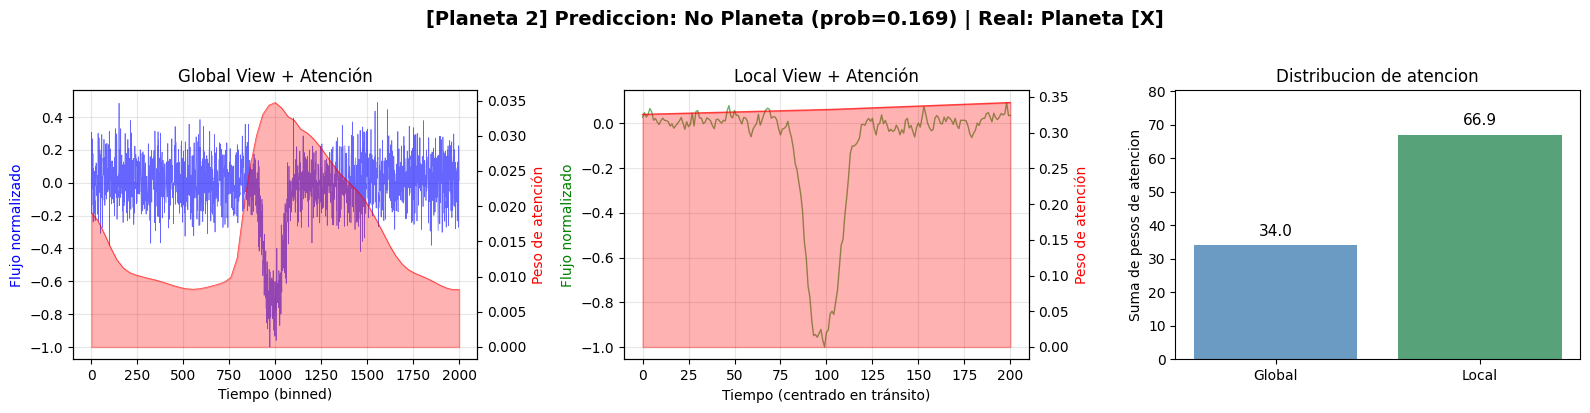

In [84]:
# Planeta 2
print("=" * 70)
print("PLANETA 2")
print("=" * 70)
idx = selected_planets[1]
features, label = test_dataset[idx]
visualize_attention(model, features, int(label.item()), title_prefix="[Planeta 2] ")

PLANETA 3


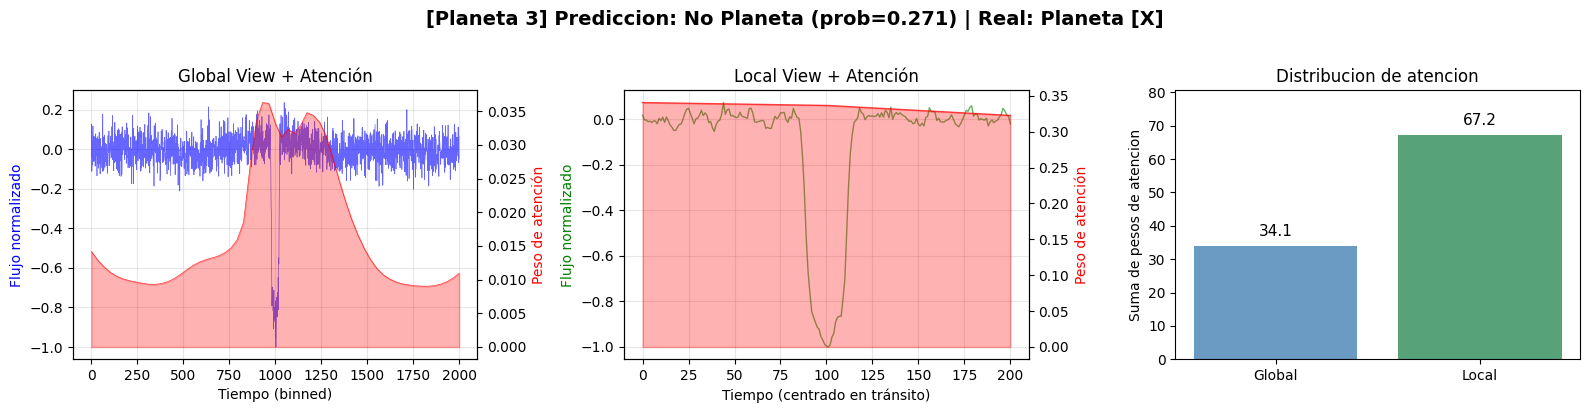

In [85]:
# Planeta 3
print("=" * 70)
print("PLANETA 3")
print("=" * 70)
idx = selected_planets[2]
features, label = test_dataset[idx]
visualize_attention(model, features, int(label.item()), title_prefix="[Planeta 3] ")

## ❌ Clase 0: No Planetas (Falsos Positivos Astrofísicos)

Visualización de la atención del modelo en 3 ejemplos de falsos positivos (binarias eclipsantes, variabilidad estelar, etc.) del conjunto de test.

NO PLANETA 1 (Falso Positivo Astrofísico)


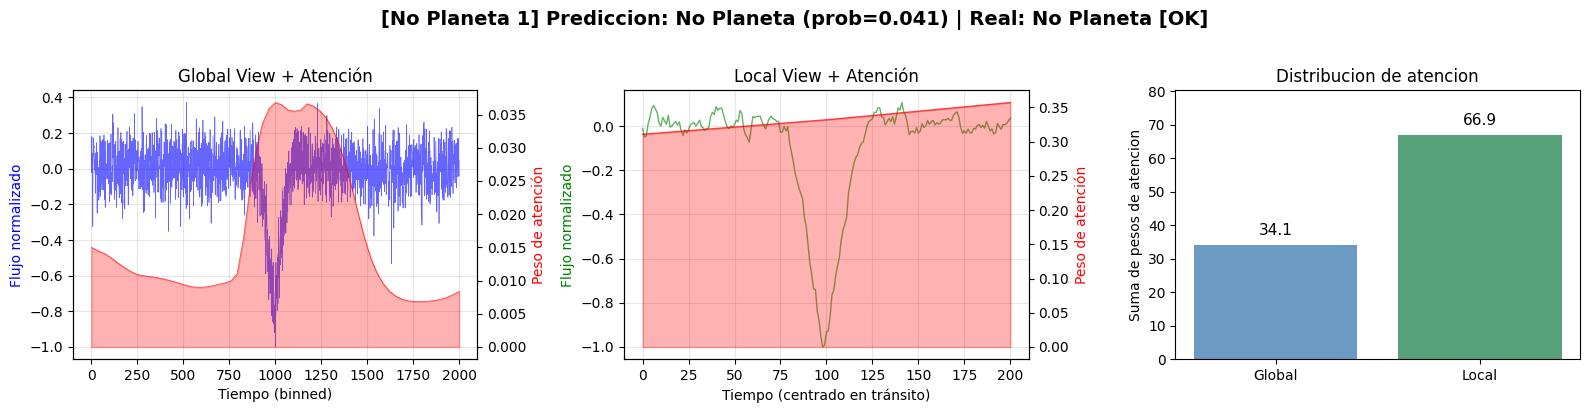

In [86]:
# No Planeta 1
print("=" * 70)
print("NO PLANETA 1 (Falso Positivo Astrofísico)")
print("=" * 70)
idx = selected_no_planets[0]
features, label = test_dataset[idx]
visualize_attention(model, features, int(label.item()), title_prefix="[No Planeta 1] ")

NO PLANETA 2 (Falso Positivo Astrofísico)


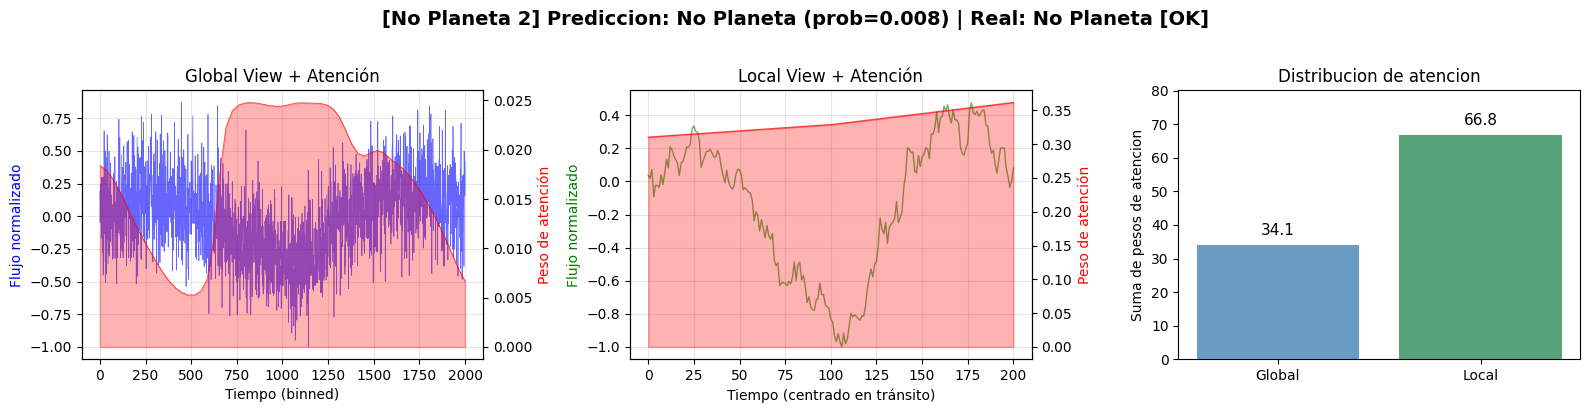

In [87]:
# No Planeta 2
print("=" * 70)
print("NO PLANETA 2 (Falso Positivo Astrofísico)")
print("=" * 70)
idx = selected_no_planets[1]
features, label = test_dataset[idx]
visualize_attention(model, features, int(label.item()), title_prefix="[No Planeta 2] ")

NO PLANETA 3 (Falso Positivo Astrofísico)


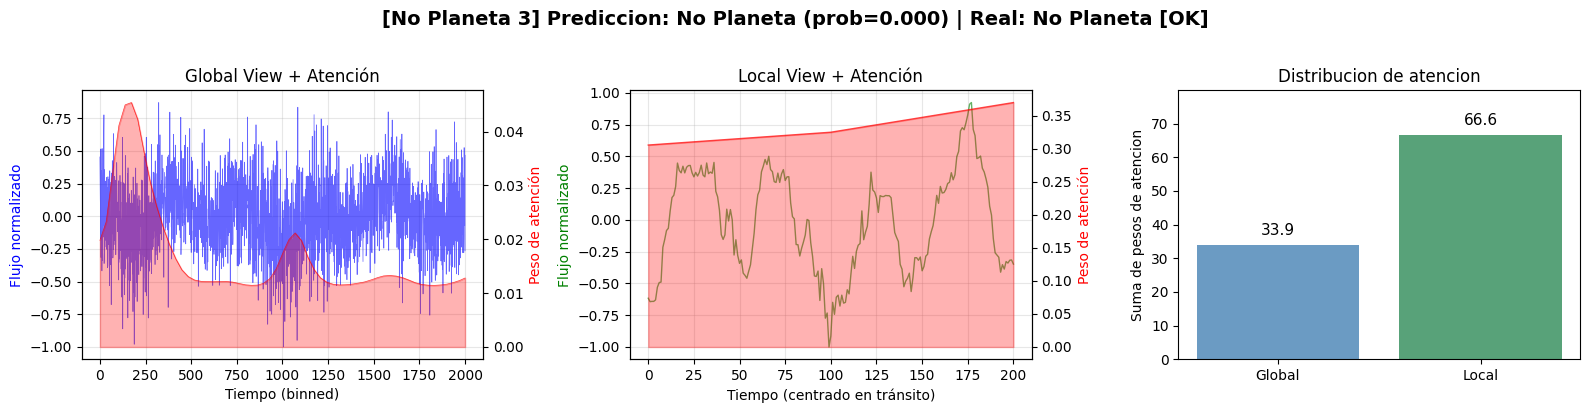

In [88]:
# No Planeta 3
print("=" * 70)
print("NO PLANETA 3 (Falso Positivo Astrofísico)")
print("=" * 70)
idx = selected_no_planets[2]
features, label = test_dataset[idx]
visualize_attention(model, features, int(label.item()), title_prefix="[No Planeta 3] ")